# Q01

Data Setup and Loading

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

D = np.genfromtxt("/content/lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

Part 1(a) - Total Least Squares (TLS)

Part 1(a): TLS Parameters for Line 1
a: -0.7736
b: 0.6337
d: -3.7942


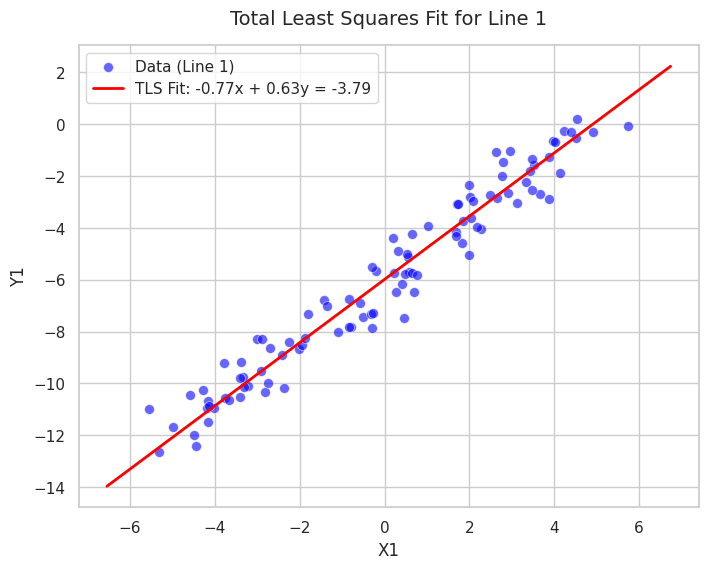

In [7]:
X1 = X_cols[:, 0]
Y1 = Y_cols[:, 0]

x_bar = np.mean(X1)
y_bar = np.mean(Y1)

U = np.column_stack((X1 - x_bar, Y1 - y_bar))

UT_U = np.dot(U.T, U)

eigenvalues, eigenvectors = np.linalg.eig(UT_U)

min_eig_idx = np.argmin(eigenvalues)
a, b = eigenvectors[:, min_eig_idx]

d = a * x_bar + b * y_bar

print("Part 1(a): TLS Parameters for Line 1")
print(f"a: {a:.4f}")
print(f"b: {b:.4f}")
print(f"d: {d:.4f}")

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X1, y=Y1, label="Data (Line 1)", color='blue', alpha=0.6, s=50)

x_vals = np.array([np.min(X1) - 1, np.max(X1) + 1])
y_vals = (d - a * x_vals) / b

sns.lineplot(x=x_vals, y=y_vals, color='red', label=f"TLS Fit: {a:.2f}x + {b:.2f}y = {d:.2f}", linewidth=2)

plt.title("Total Least Squares Fit for Line 1", fontsize=14, pad=15)
plt.xlabel("X1", fontsize=12)
plt.ylabel("Y1", fontsize=12)
plt.legend()
plt.show()

Part 1(b) - RANSAC for Multiple Lines

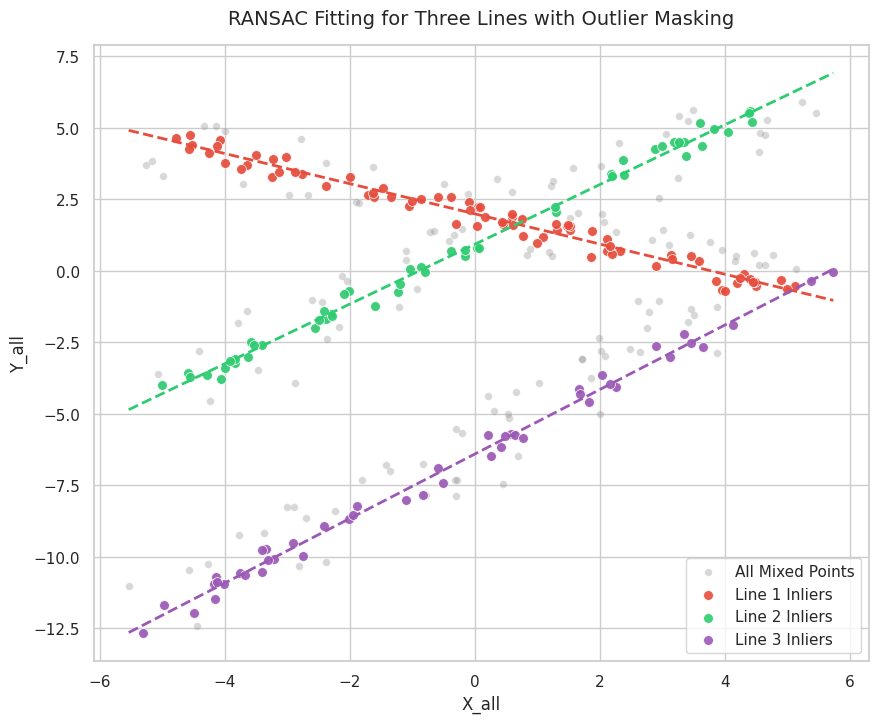

In [8]:
from sklearn.linear_model import RANSACRegressor

X_all_reshaped = X_all.reshape(-1, 1)
Y_all_reshaped = Y_all.reshape(-1, 1)

remaining_X = X_all_reshaped.copy()
remaining_Y = Y_all_reshaped.copy()

colors = ['#e74c3c', '#2ecc71', '#9b59b6']
plt.figure(figsize=(10, 8))

sns.scatterplot(x=X_all, y=Y_all, color='gray', label='All Mixed Points', alpha=0.3, s=30)

for i in range(3):
    ransac = RANSACRegressor(min_samples=2, residual_threshold=0.5, random_state=42)
    ransac.fit(remaining_X, remaining_Y)

    inlier_mask = ransac.inlier_mask_
    inlier_X = remaining_X[inlier_mask]
    inlier_Y = remaining_Y[inlier_mask]

    line_X = np.array([remaining_X.min(), remaining_X.max()]).reshape(-1, 1)
    line_Y = ransac.predict(line_X)

    sns.scatterplot(x=inlier_X.flatten(), y=inlier_Y.flatten(), color=colors[i], label=f'Line {i+1} Inliers', alpha=0.9, s=50)
    sns.lineplot(x=line_X.flatten(), y=line_Y.flatten(), color=colors[i], linewidth=2, linestyle='--')

    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

plt.title("RANSAC Fitting for Three Lines with Outlier Masking", fontsize=14, pad=15)
plt.xlabel("X_all", fontsize=12)
plt.ylabel("Y_all", fontsize=12)
plt.legend()
plt.show()

Save Plots

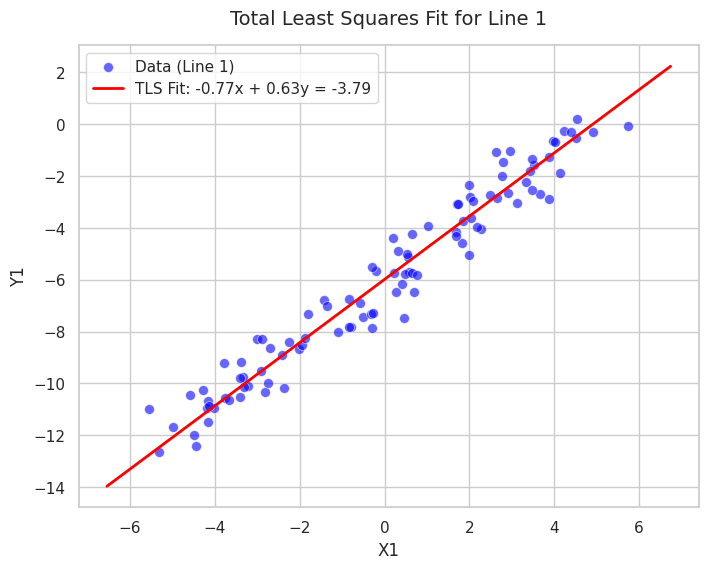

Saved 'q1a_tls_fit.png'


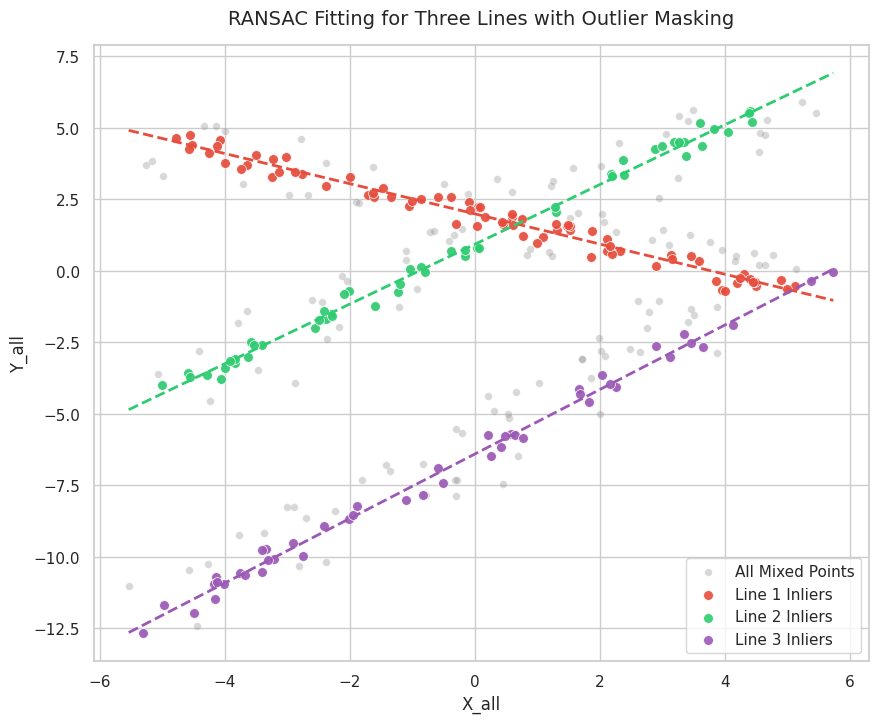

Saved 'q1b_ransac_fit.png' 


In [10]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X1, y=Y1, label="Data (Line 1)", color='blue', alpha=0.6, s=50)
sns.lineplot(x=x_vals, y=y_vals, color='red', label=f"TLS Fit: {a:.2f}x + {b:.2f}y = {d:.2f}", linewidth=2)

plt.title("Total Least Squares Fit for Line 1", fontsize=14, pad=15)
plt.xlabel("X1", fontsize=12)
plt.ylabel("Y1", fontsize=12)
plt.legend()

plt.savefig('q1a_tls_fit.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'q1a_tls_fit.png'")


remaining_X = X_all_reshaped.copy()
remaining_Y = Y_all_reshaped.copy()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_all, y=Y_all, color='gray', label='All Mixed Points', alpha=0.3, s=30)

for i in range(3):
    ransac = RANSACRegressor(min_samples=2, residual_threshold=0.5, random_state=42)
    ransac.fit(remaining_X, remaining_Y)

    inlier_mask = ransac.inlier_mask_
    inlier_X = remaining_X[inlier_mask]
    inlier_Y = remaining_Y[inlier_mask]

    line_X = np.array([remaining_X.min(), remaining_X.max()]).reshape(-1, 1)
    line_Y = ransac.predict(line_X)

    sns.scatterplot(x=inlier_X.flatten(), y=inlier_Y.flatten(), color=colors[i], label=f'Line {i+1} Inliers', alpha=0.9, s=50)
    sns.lineplot(x=line_X.flatten(), y=line_Y.flatten(), color=colors[i], linewidth=2, linestyle='--')

    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

plt.title("RANSAC Fitting for Three Lines with Outlier Masking", fontsize=14, pad=15)
plt.xlabel("X_all", fontsize=12)
plt.ylabel("Y_all", fontsize=12)
plt.legend()

plt.savefig('q1b_ransac_fit.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'q1b_ransac_fit.png' ")